In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/good/method_breakdown.csv")

results_df = pd.read_csv("../data/12k_all_results.csv")
results_df.columns


results_df["fourclass"].value_counts()
results_df["up"] = results_df["fourclass"] == "Up"
results_df["notsig"] = results_df["fourclass"] == "Not Sig"
results_df["down"] = results_df["fourclass"] == "Down"
results_df["twist_not_detected"] = ~results_df["leah_12k_twist_dna_detected"]
results_df["leah_12k_not_detected"] = ~results_df["leah_12k_detected"]
results_df = results_df[["team", "twist_not_detected", "leah_12k_not_detected", "up", "notsig", "down"]]

# if twist dna not detected true, set leah not detected to false
results_df.loc[results_df["twist_not_detected"], "leah_12k_not_detected"] = False
results_df.loc[results_df["twist_not_detected"], "notsig"] = False


results_df
results_df[["twist_not_detected", "leah_12k_not_detected", "up", "notsig", "down"]].sum().sum()

# sum by team
results_team_sum = results_df.groupby("team").sum().reset_index()

# merge with method breakdown on team
df = pd.merge(df, results_team_sum, on="team")

In [2]:
# sum by main_method column
df_sum = df.groupby("main_method").sum().reset_index().sort_values(by="main_method", ascending=False).drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

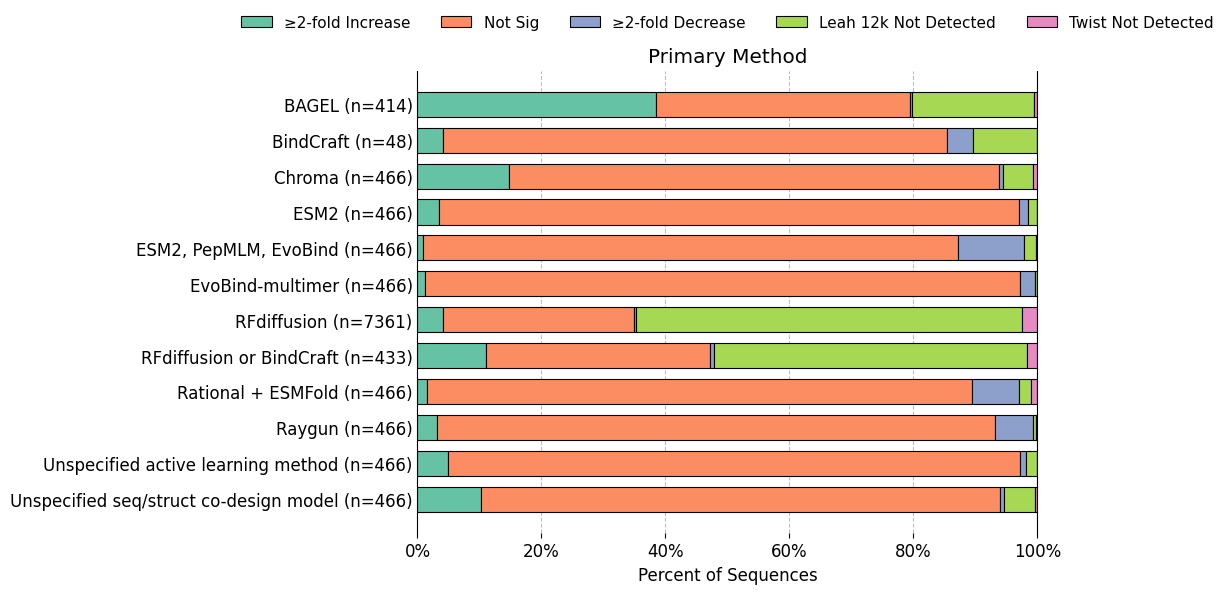

In [4]:
def plot_stacked_outcomes_by_method(
    df_sum,
    method_col="main_method",
    outcome_pct_cols=None,
    outcome_order=None,
    outcome_palette=None,
    method_labels_map=None,
    outcome_labels_map=None,
    save_dir="../results/analysis",
    save_name="stacked_outcomes_by_method",
    fig_size=None,
    title_label=None,
):
    from matplotlib.ticker import PercentFormatter

    if outcome_pct_cols is None:
        outcome_pct_cols = [c for c in df_sum.columns if c.endswith("_pct")]

    if outcome_order is None:
        outcome_order = outcome_pct_cols

    if outcome_palette is None:
        palette = sns.color_palette("Set2", n_colors=len(outcome_order))
        outcome_palette = {k: palette[i] for i, k in enumerate(outcome_order)}
    
    # reorder outcome palette for the 4th and 5th colors
    if len(outcome_order) >=5:
        outcome_palette[outcome_order[3]] = palette[4]
        outcome_palette[outcome_order[4]] = palette[3]

    if method_labels_map is not None:
        method_labels_map = {str(k): v for k, v in method_labels_map.items()}

    if outcome_labels_map is not None:
        outcome_labels_map = {str(k): v for k, v in outcome_labels_map.items()}

    methods = df_sum[method_col].astype(str).tolist()
    counts = None
    if "number_of_unique_seqs_submitted" in df_sum.columns:
        counts = df_sum["number_of_unique_seqs_submitted"].astype(int).tolist()

    plt.rcParams.update({"font.size": 12})
    if fig_size is None:
        fig_width = max(4, 0.8 * len(methods))
        fig_size = (fig_width, 4)
    fig, ax = plt.subplots(figsize=fig_size)

    y = list(range(len(methods)))
    left = [0.0] * len(methods)

    for outcome in outcome_order:
        widths = (df_sum[outcome].fillna(0.0) * 100.0).tolist()
        ax.barh(
            y,
            widths,
            left=left,
            color=outcome_palette.get(outcome, None),
            height=0.7,
            edgecolor="black",
            linewidth=0.8,
            label=(outcome_labels_map.get(outcome, outcome) if outcome_labels_map else outcome),
        )
        left = [b + w for b, w in zip(left, widths)]

    if method_labels_map is not None:
        method_names = [method_labels_map.get(m, m) for m in methods]
    else:
        method_names = methods

    if counts is not None:
        xticklabels = [f"{m} (n={n})" for m, n in zip(method_names, counts)]
    else:
        xticklabels = method_names

    ax.set_yticks(y)
    ax.set_yticklabels(xticklabels)
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percent of Sequences")
    ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
    # ax.legend(
    #     frameon=False,
    #     fontsize=11,
    #     bbox_to_anchor=(1.02, 0.5),
    #     loc="center left",
    #     ncol=1,
    # )

    # # legend on top
    ax.legend(
        frameon=False,
        fontsize=11,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(outcome_order),
    )


    # reverse the legend order
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::-1], labels[::-1], frameon=False, fontsize=11, bbox_to_anchor=(1.02, 0.5), loc="center left", ncol=1)

    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    # ax.spines["left"].set_visible(False)

    # major gridlines on
    ax.xaxis.grid(True, which="major", linestyle="--", linewidth=0.8, color="gray", alpha=0.5)
    ax.set_axisbelow(True)

    if title_label is not None:
        ax.set_title(title_label)

    out_path = f"{save_dir}/{save_name}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()


# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="main_method",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "≥2-fold Increase",
        "notsig_pct": "Not Sig",
        "down_pct": "≥2-fold Decrease",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(8, 6),
    save_name="stacked_outcomes_by_method",
    title_label="Primary Method",
)


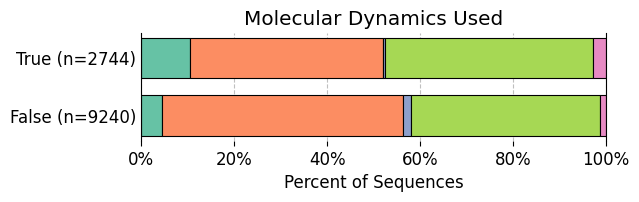

In [ ]:

# sum by main_method column
# df["md_used"] = df["md"].apply(lambda x: "MD Used" if x == True else "MD Not Used")
df["md_used"] = df["md"]
df_sum = df.groupby("md_used").sum().reset_index().sort_values(by="md_used").drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="md_used",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(6, 1.4),
    save_name="stacked_outcomes_md",
    title_label="Molecular Dynamics Used",
)


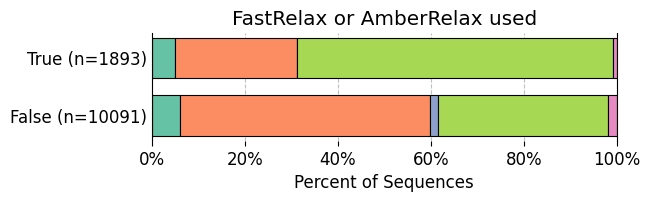

In [ ]:

# sum by main_method column
# df["relax_used"] = df["fast/amberrelax"].apply(lambda x: "FastRelax Used" if x == True else "FastRelax Not Used")
df["relax_used"] = df["fast/amberrelax"]
df_sum = df.groupby("relax_used").sum().reset_index().sort_values(by="relax_used").drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="relax_used",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(6, 1.4),
    save_name="stacked_outcomes_relax",
    title_label="FastRelax or AmberRelax used",
)


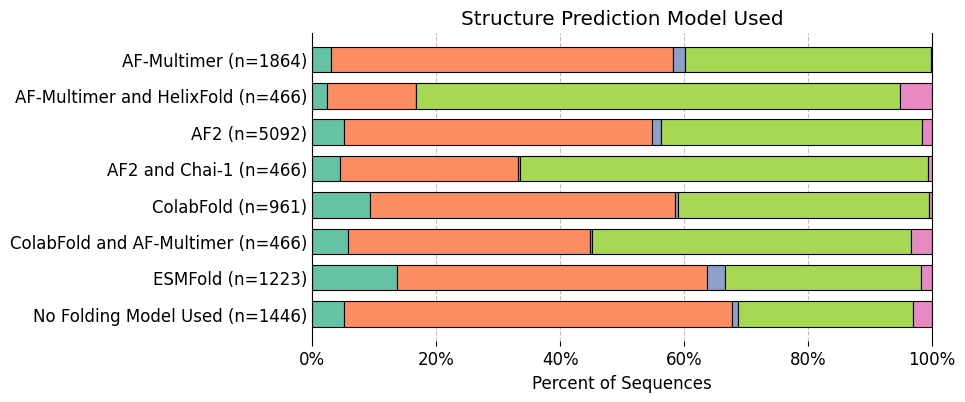

In [ ]:

# sum by main_method column
df["folding_model"] = df["folding_model"].fillna("No Folding Model Used")
df_sum = df.groupby("folding_model").sum().reset_index().sort_values(by="folding_model").drop(columns=["team"])
df_sum = df_sum.sort_values(by="folding_model", ascending=False)

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="folding_model",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(8, 4),
    save_name="stacked_outcomes_folding_model",
    title_label="Structure Prediction Model Used",
)


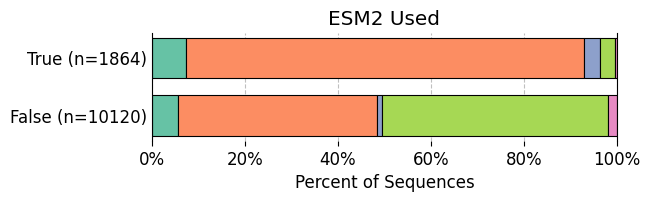

In [ ]:

# sum by main_method column
# df["esm2_used"] = df["ESM2_used"].apply(lambda x: "ESM2 Used" if x == True else "ESM2 Not Used")
df["esm2_used"] = df["ESM2_used"]
df_sum = df.groupby("esm2_used").sum().reset_index().sort_values(by="esm2_used").drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="esm2_used",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(6, 1.4),
    save_name="stacked_outcomes_esm2_used",
    title_label="ESM2 Used",
)


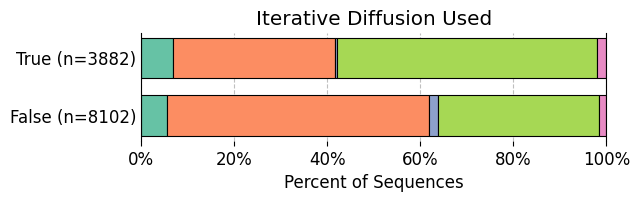

In [ ]:

# sum by main_method column
# df["iterative_diffusion_used"] = df["iterative_diffusion"].apply(lambda x: "Iterative Diffusion Used" if x == True else "Iterative Diffusion Not Used")
df["iterative_diffusion_used"] = df["iterative_diffusion"]
df_sum = df.groupby("iterative_diffusion_used").sum().reset_index().sort_values(by="iterative_diffusion_used").drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="iterative_diffusion_used",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(6, 1.4),
    save_name="stacked_outcomes_iterative_diffusion_used",
    title_label="Iterative Diffusion Used",
)


In [ ]:

# # sum by main_method column
# df["MPNN_model"] = df["MPNN_model"].astype(str).replace("nan", "No MPNN")

# df_sum = df.groupby("MPNN_model").sum().reset_index().sort_values(by="MPNN_model").drop(columns=["team"])

# # compute percentages
# df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
# df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
# df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
# df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
# df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# # # stacked outcomes for each method
# plot_stacked_outcomes_by_method(
#     df_sum,
#     method_col="MPNN_model",
#     outcome_order=[
#         "up_pct",
#         "notsig_pct",
#         "down_pct",
#         "leah_12k_not_detected_pct",
#         "twist_not_detected_pct",
#     ],
#     outcome_labels_map={
#         "up_pct": "Up",
#         "notsig_pct": "Not Sig",
#         "down_pct": "Down",
#         "leah_12k_not_detected_pct": "Leah 12k Not Detected",
#         "twist_not_detected_pct": "Twist Not Detected",
#     },
#     fig_size=(6, 1.5),
#     save_name="stacked_outcomes_mpnn",
# )


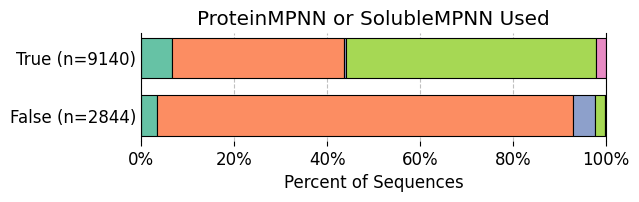

In [ ]:

# sum by main_method column
df["MPNN_model"] = df["MPNN_model"].astype(str).replace("nan", "No MPNN")
# df["mpnn_bool"] = df["MPNN_model"].apply(lambda x: "MPNN Not Used" if x == "No MPNN" else "MPNN Used")
df["mpnn_bool"] = df["MPNN_model"].apply(lambda x: False if x == "No MPNN" else True)

df_sum = df.groupby("mpnn_bool").sum().reset_index().sort_values(by="mpnn_bool").drop(columns=["team"])

# compute percentages
df_sum["up_pct"] = df_sum["up"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["notsig_pct"] = df_sum["notsig"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["down_pct"] = df_sum["down"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["twist_not_detected_pct"] = df_sum["twist_not_detected"] / df_sum["number_of_unique_seqs_submitted"]
df_sum["leah_12k_not_detected_pct"] = df_sum["leah_12k_not_detected"] / df_sum["number_of_unique_seqs_submitted"]

# stacked outcomes for each method
plot_stacked_outcomes_by_method(
    df_sum,
    method_col="mpnn_bool",
    outcome_order=[
        "up_pct",
        "notsig_pct",
        "down_pct",
        "leah_12k_not_detected_pct",
        "twist_not_detected_pct",
    ],
    outcome_labels_map={
        "up_pct": "Up",
        "notsig_pct": "Not Sig",
        "down_pct": "Down",
        "leah_12k_not_detected_pct": "Leah 12k Not Detected",
        "twist_not_detected_pct": "Twist Not Detected",
    },
    fig_size=(6, 1.4),
    save_name="stacked_outcomes_mpnn",
    title_label="ProteinMPNN or SolubleMPNN Used",
)
